# Polymarket trader microstructure — Step 1: load and clean

Load path for the trader-level parquet (`data/data.parquet`, raw N = 604,578).
This section calls `src/data_loader.py` rather than duplicating cleaning logic.

In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_loader import COORD_COLS, PERF_COLS, get_topic_columns, load_and_clean_data

DATA_PATH = ROOT / "data" / "data.parquet"

df = load_and_clean_data(str(DATA_PATH))
print(f"cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"topic share columns: {len(get_topic_columns(df))}")
df.head()

cleaned shape: 600,421 rows x 43 cols
topic share columns: 17


,trader,trader_pnl,trader_volume,transaction_count,transactions_per_day,volume_per_day,markets_per_day,price_levels_consumed,price_levels_per_transaction,price_levels_consumed_vw,...,price_levels_per_volume,trader_ppv,mean_tx_value,std_tx_value,std_time_vw,trader_label,largest_transformers_topic_share,largest_tags_topic_share,log_mean_tx_value,log_volume
0,0xBb9959a61D6cCE2904e0eC3caD30bEB354C47415,97.569646,9142.382672,369,4.392857,108.837889,1.845238,0.307,0.000832,6.508426,...,0.000712,0.010672,18.670875,35.750894,2.245478e+07,good,0.548144,0.544607,1.293824,3.961107
1,0x4b13F31fcB0Ea4daF8F5b16e518202cdf647Cd7c,0.656000,94.000000,11,3.666667,31.333333,1.666667,0.000,0.000000,0.000000,...,0.000000,0.006979,4.576727,3.490607,2.810942e+07,good,0.853806,0.536310,0.746379,1.977724
2,0x8C53E5E9eff97b5dDCD8550Fef8B94E405bd3129,-7.079997,50.262833,7,2.333333,16.754278,2.000000,0.000,0.000000,0.000000,...,0.000000,-0.140859,3.274285,3.930220,1.793309e+06,awful,0.912740,0.759230,0.630864,1.709803
3,0x5989DAb26713ac1408c7E0a370F4AF41d7f4d88A,-4.106590,29.655189,6,1.500000,7.413797,1.250000,0.000,0.000000,0.000000,...,0.000000,-0.138478,3.974780,3.108597,2.883624e+07,awful,0.536253,0.876723,0.696774,1.486504
4,0x17Fb7317502333EE27d0712570b7AaDF18C4C026,159.214413,588.714406,5,1.000000,117.742881,1.000000,0.000,0.000000,0.000000,...,0.000000,0.270444,58.899999,39.368388,1.087001e+07,sharp,0.446520,0.887946,1.777427,2.770642


In [4]:
# sanity: required fields are finite, labels filled, log columns present
check_cols = list(COORD_COLS + PERF_COLS) + ["log_mean_tx_value", "log_volume"]
nan_counts = df[check_cols].isna().sum()
inf_counts = np.isinf(df[check_cols].to_numpy()).sum(axis=0)

qa = pd.DataFrame(
    {"nan": nan_counts.to_numpy(), "inf": inf_counts},
    index=check_cols,
)
print("label fill (Unlabeled count):", int((df["trader_label"] == "Unlabeled").sum()))
print("unique labels:", sorted(df["trader_label"].dropna().unique().tolist()))
qa

label fill (Unlabeled count): 0
unique labels: ['awful', 'bad', 'good', 'sharp']


,nan,inf
price_levels_consumed_vw,0,0
std_time_vw,0,0
mean_tx_value,0,0
trader_pnl,0,0
trader_volume,0,0
trader_ppv,0,0
log_mean_tx_value,0,0
log_volume,0,0


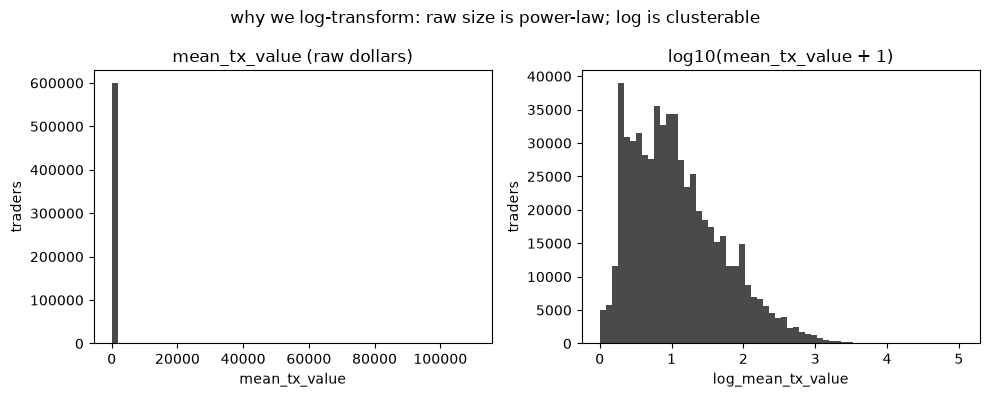

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["mean_tx_value"], bins=60, color="#4a4a4a")
axes[0].set_title("mean_tx_value (raw dollars)")
axes[0].set_xlabel("mean_tx_value")
axes[0].set_ylabel("traders")

axes[1].hist(df["log_mean_tx_value"], bins=60, color="#4a4a4a")
axes[1].set_title("log10(mean_tx_value + 1)")
axes[1].set_xlabel("log_mean_tx_value")
axes[1].set_ylabel("traders")

fig.suptitle("why we log-transform: raw size is power-law; log is clusterable")
fig.tight_layout()
plt.show()

## Why this cleaning

**Log-transform financial size before clustering.**  
`mean_tx_value` and `trader_volume` are heavy-tailed (median trade size ~$8, max ~$110k; median volume ~$148, max ~$92M). k-means and other Euclidean clusterers treat distance in raw dollars as linear, so a handful of whales would own entire axes and collapse everyone else into one blob. `log10(x + 1)` compresses orders of magnitude into a roughly linear scale, keeps zeros defined, and makes nearest-neighbor distances reflect *relative* size (10 vs 100 vs 1,000) instead of absolute dollars.

**Missing-data strategy.**
1. `trader_label` is categorical metadata, not a coordinate. Fill nulls with `"Unlabeled"` so we keep the row and can still plot/filter it. (In this parquet the column is already complete; the fill is a safe default.)
2. Core 3D coordinates (`price_levels_consumed_vw`, `std_time_vw`, `mean_tx_value`) and performance (`trader_pnl`, `trader_volume`, `trader_ppv`) are required to place a trader in space and to interpret clusters. Nulls and +-inf (this file has ~4,156 nulls and 1 inf on `std_time_vw`) cannot be imputed without inventing a location, so those rows are dropped.
3. Other columns (e.g. `std_delta` on single-trade wallets) are left as-is; they are not needed for the 3D embedding in later steps.

Net effect on this file: **4,157 rows dropped**, **600,421 remain**, plus two new columns: `log_mean_tx_value` and `log_volume`.

# Step 2: feature engineering

Turn the cleaned Step 1 frame into (1) a concentration score `hhi` and (2) a z-scored 3D matrix `X_scaled` for density clustering.
This cell uses `src/feature_engineering.py` on the `df` from Step 1.

In [6]:
from src.feature_engineering import SPATIAL_FEATURE_COLS, engineer_features

df, X_scaled = engineer_features(df)

print(f"feature frame: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"spatial axes: {list(SPATIAL_FEATURE_COLS)}")
print(f"X_scaled column means: {X_scaled.mean(axis=0)}")
print(f"X_scaled column stds:  {X_scaled.std(axis=0)}")
df[["hhi", "z_price_levels_consumed_vw", "z_std_time_vw", "z_log_mean_tx_value"]].describe()

feature frame: 600,421 rows x 47 cols
X_scaled shape: (600421, 3)
spatial axes: ['price_levels_consumed_vw', 'std_time_vw', 'log_mean_tx_value']
X_scaled column means: [-1.89345206e-18  5.86970138e-17 -1.21370277e-16]
X_scaled column stds:  [1. 1. 1.]


,hhi,z_price_levels_consumed_vw,z_std_time_vw,z_log_mean_tx_value
count,600421.000000,6.004210e+05,6.004210e+05,6.004210e+05
mean,0.662403,-1.893452e-18,5.869701e-17,-1.213703e-16
std,0.280890,1.000001e+00,1.000001e+00,1.000001e+00
min,0.121383,-3.400251e-02,-1.114012e+00,-1.704626e+00
25%,0.404895,-3.400251e-02,-1.008041e+00,-7.931701e-01
50%,0.583596,-3.400251e-02,-1.418370e-01,-1.573355e-01
75%,1.000000,-3.397269e-02,7.565159e-01,6.080826e-01
max,1.000000,2.933536e+02,4.941193e+01,6.257777e+00


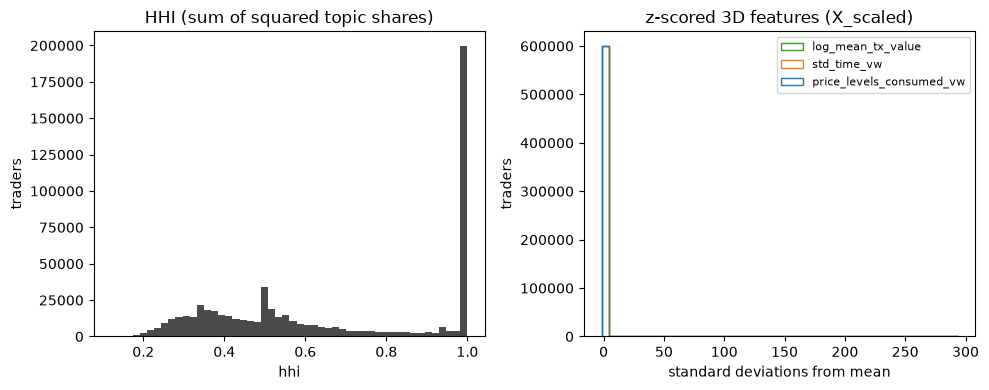

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df["hhi"], bins=50, color="#4a4a4a")
axes[0].set_title("HHI (sum of squared topic shares)")
axes[0].set_xlabel("hhi")
axes[0].set_ylabel("traders")

axes[1].hist(X_scaled, bins=50, histtype="step", label=list(SPATIAL_FEATURE_COLS))
axes[1].set_title("z-scored 3D features (X_scaled)")
axes[1].set_xlabel("standard deviations from mean")
axes[1].set_ylabel("traders")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

We measure topic concentration with the Herfindahl–Hirschman Index, $\mathrm{HHI}_i = \sum_c s_{i,c}^2$, over the 17 IPTC `topic_*` share columns; because shares already sum to one, squaring maps a pure specialist to $\mathrm{HHI}=1$ while spreading activity across categories drives HHI toward $1/C$, so high HHI isolates domain specialists rather than high-volume generalists. Spatial clustering uses the three-dimensional matrix $(\texttt{price\_levels\_consumed\_vw},\ \texttt{std\_time\_vw},\ \texttt{log\_mean\_tx\_value})$. Z-score standardization, $x'=(x-\mu)/\sigma$ via `StandardScaler`, is mandatory for DBSCAN/HDBSCAN: those algorithms treat Euclidian distance as comparable across axes, and without it the millisecond-scale `std_time_vw` would dominate book-walking and log-size, so neighborhood radii would no longer be unit-agnostic.

# Step 3: HDBSCAN spatial clustering

Fit `SpatialPointModel` on `X_scaled` from Step 2. Cluster `-1` is unstructured spatial noise; labels `>= 0` are dense execution manifolds. `outlier_score` is the GLOSH outlier probability (higher = more locally sparse).

In [8]:
from src.spatial_model import SpatialPointModel, summarize_clusters

spatial_model = SpatialPointModel(min_cluster_size=50, min_samples=15)
df = spatial_model.fit_attach(df, X_scaled)

n_noise = int((df["spatial_cluster"] == -1).sum())
n_manifolds = int(df["spatial_cluster"].max() + 1) if df["spatial_cluster"].max() >= 0 else 0
print(f"manifolds (cluster >= 0): {n_manifolds}")
print(f"noise (cluster == -1): {n_noise:,} ({100 * n_noise / len(df):.1f}%)")
print(f"outlier_score median: {df['outlier_score'].median():.4f}")
df[["spatial_cluster", "outlier_score"]].head()

manifolds (cluster >= 0): 1684
noise (cluster == -1): 373,773 (62.3%)
outlier_score median: 1.0000


,spatial_cluster,outlier_score
0,-1,1.0
1,288,0.0
2,-1,1.0
3,218,0.0
4,-1,1.0


In [9]:
cluster_summary = summarize_clusters(df)
print("noise pool is spatial_cluster == -1")
print("pct_*_vs_noise is percentage points vs that pool")
cluster_summary.sort_values("n_traders", ascending=False).head(12)

noise pool is spatial_cluster == -1
pct_*_vs_noise is percentage points vs that pool


,spatial_cluster,n_traders,mean_trader_ppv,median_trader_pnl,pct_sharp,pct_awful,pct_sharp_vs_noise,pct_awful_vs_noise,is_noise
0,-1,373773,-0.021732,-0.174140,15.739500,19.844398,0.000000,0.000000,True
1173,1172,2160,-0.002407,0.000000,1.064815,1.759259,-14.674685,-18.085138,False
636,635,1850,-0.301199,-16.401539,4.216216,85.297297,-11.523283,65.452900,False
638,637,1845,-0.017951,-0.201804,23.035230,28.130081,7.295731,8.285684,False
635,634,1705,-0.325789,-16.601498,3.167155,88.739003,-12.572344,68.894605,False
1477,1476,1543,0.039885,0.041667,99.416721,0.064809,83.677221,-19.779589,False
947,946,1450,-0.019640,-0.196917,18.620690,21.724138,2.881190,1.879740,False
1461,1460,1416,0.031000,0.031991,0.000000,0.000000,-15.739500,-19.844398,False
1300,1299,1171,-0.013461,0.052650,3.415884,5.294620,-12.323616,-14.549778,False
963,962,1060,-0.028868,-0.641107,24.245283,32.641509,8.505783,12.797112,False


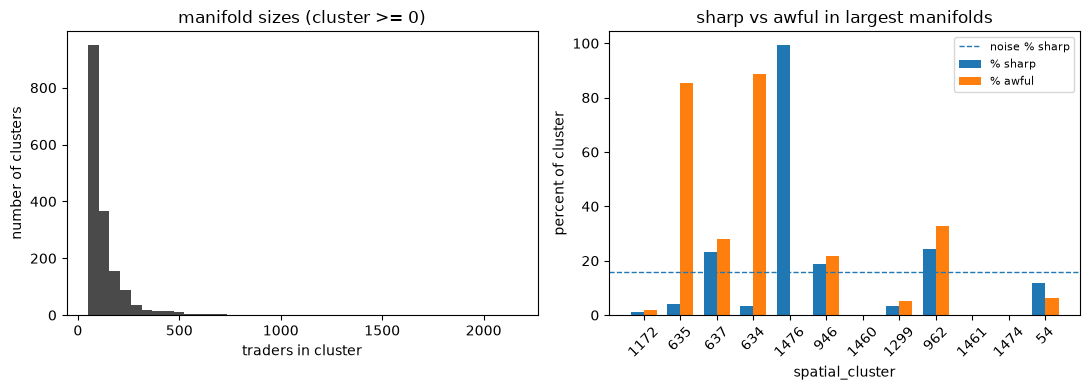

In [10]:
top = cluster_summary.loc[~cluster_summary["is_noise"]].nlargest(12, "n_traders")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df.loc[df["spatial_cluster"] != -1, "spatial_cluster"].value_counts(), bins=40, color="#4a4a4a")
axes[0].set_title("manifold sizes (cluster >= 0)")
axes[0].set_xlabel("traders in cluster")
axes[0].set_ylabel("number of clusters")

x = range(len(top))
axes[1].bar([i - 0.18 for i in x], top["pct_sharp"], width=0.36, label="% sharp")
axes[1].bar([i + 0.18 for i in x], top["pct_awful"], width=0.36, label="% awful")
axes[1].axhline(cluster_summary.loc[cluster_summary["is_noise"], "pct_sharp"].iloc[0], linestyle="--", linewidth=1, label="noise % sharp")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(top["spatial_cluster"].astype(int).astype(str), rotation=45)
axes[1].set_title("sharp vs awful in largest manifolds")
axes[1].set_xlabel("spatial_cluster")
axes[1].set_ylabel("percent of cluster")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## What `min_cluster_size` and `min_samples` control

`min_cluster_size=50` is the smallest group HDBSCAN is allowed to call a cluster: a dense blob with fewer than 50 traders is merged upward or declared noise, so we do not treat tiny lucky clumps as execution manifolds. `min_samples=15` is the core-point threshold: a trader is "core" only if at least 15 neighbors sit within its reachability neighborhood; smaller `min_samples` makes the manifold more inclusive (and noisier), larger `min_samples` makes it stricter.

## How HDBSCAN assigns noise (`-1`) versus core membership

HDBSCAN builds a hierarchy of density-connected components, then cuts it with Excess of Mass. Points that persist inside a component of size at least `min_cluster_size` receive a label `>= 0` (a dense execution manifold). Points that never sit in such a component — they are density-disconnected, in sparse gaps, or in groups smaller than 50 — get `spatial_cluster = -1` (unstructured spatial noise). `outlier_score` is the GLOSH score in \([0,1]\): low values are locally typical of a dense region; high values are locally sparse, including most of the noise pool.

# Step 4: publication figures

Interactive 3D scatter (Plotly) of execution style, plus a 2D Sharp-share comparison (Seaborn). The 3D view is a **stratified subsample** — plotting all 600k points is not interactive. Clustering itself still used the full `X_scaled` matrix.

In [11]:
from pathlib import Path
import sys

from IPython.display import HTML, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.visualize import (
    build_3d_scatter,
    export_plotly_png,
    plot_sharp_dense_vs_noise,
    sample_for_3d_plot,
    sharp_share_dense_vs_noise,
)

FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plot_df = sample_for_3d_plot(df)
print(f"3D sample size: {len(plot_df):,} (full N={len(df):,})")
print(plot_df["spatial_cluster"].value_counts().head(8).to_string())

fig_3d = build_3d_scatter(plot_df)
png_3d = export_plotly_png(fig_3d, FIGURES / "3d_spatial_clusters.png", scale=3)
print(f"wrote {png_3d}")
#html embed
display(HTML(fig_3d.to_html(include_plotlyjs="cdn", full_html=False)))

3D sample size: 6,800 (full N=600,421)
spatial_cluster
-1       2000
 1172     350
 635      350
 637      350
 634      350
 1476     350
 946      350
 1460     350
wrote /Users/lilyshen/polymarket-analysis/figures/3d_spatial_clusters.png


Three-dimensional map of Polymarket trader execution style. Axes are volume-weighted price-book impact (`price_levels_consumed_vw`), volume-weighted time-of-day dispersion (`std_time_vw`), and log order size (`log_mean_tx_value = \log_{10}(\texttt{mean\_tx\_value}+1)`). Color is the HDBSCAN spatial cluster treated as a categorical label (the twelve largest dense manifolds are shown separately; remaining dense points are grouped as *other dense*; unstructured points are *noise*, label $-1$). Marker symbol is the provided trader label (Sharp, Good, Bad, Awful). Hover fields report `trader_pnl`, `trader_ppv`, and topic-concentration HHI (`hhi`). For readability the figure displays a stratified subsample of the $N=600{,}421$ clustered sample (largest manifolds, a slice of other dense points, and a cap on noise); cluster membership itself was estimated on the full z-scored matrix.

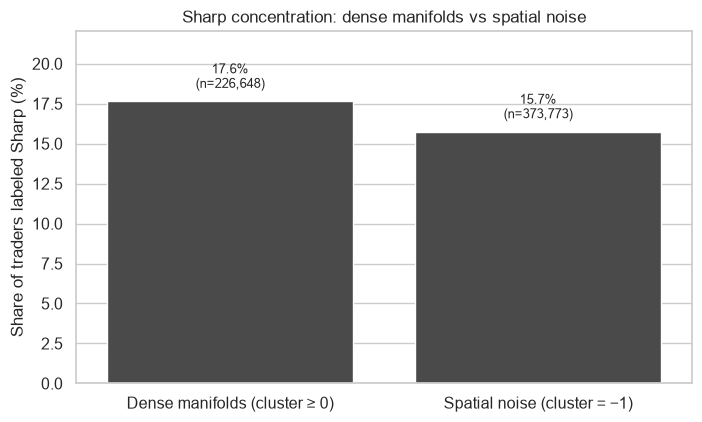

,pool,n_traders,pct_sharp
0,Dense manifolds (cluster ≥ 0),226648,17.642776
1,Spatial noise (cluster = −1),373773,15.739500


In [12]:
sharp_stats = plot_sharp_dense_vs_noise(
    df, png_path=FIGURES / "sharp_share_dense_vs_noise.png"
)
plt.show()
sharp_stats

Share of traders labeled Sharp in dense HDBSCAN execution manifolds (`spatial_cluster` $\ge 0$) versus the unstructured spatial noise pool (`spatial_cluster` $= -1$). In the full clustered sample ($N=600{,}421$), Sharp accounts for 17.6% of dense-manifold traders ($n=226{,}648$) and 15.7% of noise ($n=373{,}773$). The gap is small: labeled high-PPV wallets are only mildly over-represented in repeating execution geometries. This comparison is descriptive: `trader_label` is a function of `trader_ppv` and is not an independent skill tag.

# Step 5: cluster autopsy, base rates, and book-impact degeneracy

These tables reuse `df` from Step 3 (must already have `spatial_cluster`). If you skip HDBSCAN, the next cell reloads the cleaned parquet and attaches labels from `web/data/points.bin` (same row order as `load_and_clean_data` → `engineer_features`). PNGs are written to `figures/`.

In [13]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.data_loader import load_and_clean_data
from src.feature_engineering import engineer_features

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

# reuse step 3 labels if present; otherwise reload + attach exported ids
if "df" not in globals() or "spatial_cluster" not in getattr(df, "columns", []):
    df = load_and_clean_data(ROOT / "data" / "data.parquet")
    df, _ = engineer_features(df)

if "spatial_cluster" not in df.columns:
    n = len(df)
    buf = (ROOT / "web" / "data" / "points.bin").read_bytes()
    off = 10 * n * 4
    df = df.copy()
    df["spatial_cluster"] = np.frombuffer(buf, dtype="<i2", count=n, offset=off)

lab = df["trader_label"].astype("string").str.lower()
df = df.copy()
df["_label"] = lab
df["_sharp"] = lab == "sharp"
df["_awful"] = lab == "awful"
df["_bad"] = lab == "bad"
df["_good"] = lab == "good"
NOISE = df["spatial_cluster"] == -1
print(f"rows: {len(df):,} | noise: {int(NOISE.sum()):,} ({100 * NOISE.mean():.1f}%)")

rows: 600,421 | noise: 373,773 (62.3%)


## Table 1 — cluster autopsy

Cluster **1476** is the ~99% Sharp ball. Clusters **634** and **635** are the >85% Awful balls. **Noise** is everyone HDBSCAN did not put in a dense manifold (`spatial_cluster = -1`). Columns: group size, then medians of `transaction_count`, `trader_volume`, and `trader_ppv`, plus the share of each group labeled Sharp / Awful.

,cluster,n,median_trades,median_volume,median_ppv,pct_sharp,pct_awful
0,1476,"1,543",1,$1.04,+0.0400,99.4%,0.1%
1,634,"1,705",2,$43.71,-0.3820,3.2%,88.7%
2,635,"1,850",2,$44.77,-0.3675,4.2%,85.3%
3,noise (−1),"373,773",8,$228.00,-0.0009,15.7%,19.8%


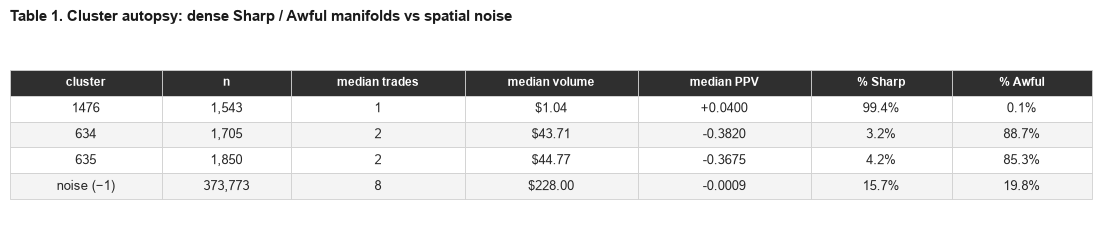

saved /Users/lilyshen/polymarket-analysis/figures/table_cluster_autopsy.png
1476 extras: 100.0% have 1 trade; 98.4% have std_time_vw=0; median mean_tx_value=$1.00; median HHI=1.00


In [21]:
def _paper_table(df_tbl, col_labels, title, out_name, col_widths=None):
    """draw a matplotlib table and save a png."""
    n_rows, n_cols = df_tbl.shape
    fig_h = 0.55 + 0.42 * (n_rows + 1)
    fig, ax = plt.subplots(figsize=(11.2, fig_h))
    ax.axis("off")
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold", pad=8, color="#1a1a1a")
    table = ax.table(
        cellText=df_tbl.values,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.55)
    if col_widths:
        for i, w in enumerate(col_widths):
            for r in range(n_rows + 1):
                table[(r, i)].set_width(w)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("#d0d0d0")
        cell.set_linewidth(0.6)
        if r == 0:
            cell.set_facecolor("#2f2f2f")
            cell.set_text_props(color="white", fontweight="bold", fontsize=8.5)
        elif r % 2 == 0:
            cell.set_facecolor("#f4f4f4")
        else:
            cell.set_facecolor("white")
    fig.tight_layout()
    path = FIGURES / out_name
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved", path)
    return path


def _autopsy_row(mask, name):
    g = df.loc[mask]
    return {
        "cluster": name,
        "n": f"{len(g):,}",
        "median_trades": f"{g['transaction_count'].median():.0f}",
        "median_volume": f"${g['trader_volume'].median():,.2f}",
        "median_ppv": f"{g['trader_ppv'].median():+.4f}",
        "pct_sharp": f"{100 * g['_sharp'].mean():.1f}%",
        "pct_awful": f"{100 * g['_awful'].mean():.1f}%",
    }


autopsy = pd.DataFrame([
    _autopsy_row(df["spatial_cluster"] == 1476, "1476"),
    _autopsy_row(df["spatial_cluster"] == 634, "634"),
    _autopsy_row(df["spatial_cluster"] == 635, "635"),
    _autopsy_row(NOISE, "noise (−1)"),
])
display(autopsy)
_paper_table(
    autopsy,
    col_labels=["cluster", "n", "median trades", "median volume", "median PPV", "% Sharp", "% Awful"],
    title="Table 1. Cluster autopsy: dense Sharp / Awful manifolds vs spatial noise",
    out_name="table_cluster_autopsy.png",
    col_widths=[0.14, 0.12, 0.16, 0.16, 0.16, 0.13, 0.13],
)

g1476 = df.loc[df["spatial_cluster"] == 1476]
print(
    f"1476 extras: {100*(g1476['transaction_count']==1).mean():.1f}% have 1 trade; "
    f"{100*(g1476['std_time_vw']==0).mean():.1f}% have std_time_vw=0; "
    f"median mean_tx_value=${g1476['mean_tx_value'].median():.2f}; median HHI={g1476['hhi'].median():.2f}"
)

**Table 1 caption.** Four-row autopsy of the two headline manifolds and the noise pool. Cluster 1476 ($n=1{,}543$) is 99.4% Sharp with median 1 trade, median volume $\approx\$1.04$, and median PPV $=+0.040$ — i.e. one-dollar single tickets that just clear the Sharp cutoff, not TWAP/VWAP bots (`std_time_vw=0` on a 1-trade wallet is identity, not an algo). Clusters 634 ($n=1{,}705$) and 635 ($n=1{,}850$) are 88.7% and 85.3% Awful, median 2 trades, median volume $\approx\$44$, median PPV $\approx -0.38$ / $-0.37$. Noise ($n=373{,}773$) sits in between: median 8 trades, median volume $\$228$, median PPV $\approx 0$, 15.7% Sharp / 19.8% Awful. Dense geometry tracks **clip size and ticket count**, not scalable skill.

## Table 2 — base-rate comparison

**62.3% of all traders are noise.** So “X% of label Y sit in noise” is only interesting if it differs from 62.3%. This table is: among all wallets with label $Y$, what fraction have `spatial_cluster = -1`, and how many percentage points that is from the 62.3% base rate.

noise base rate: 62.3%  (373,773 / 600,421)


,label,n,n_in_noise,pct_of_label_in_noise,vs_62.3pct_base
0,Awful,"124,718","74,173",59.5%,-2.8 pp
1,Bad,"197,007","139,572",70.8%,+8.6 pp
2,Good,"179,879","101,198",56.3%,-6.0 pp
3,Sharp,"98,817","58,830",59.5%,-2.7 pp
4,Awful + Bad,"321,725","213,745",66.4%,+4.2 pp
5,all traders,"600,421","373,773",62.3%,+0.0 pp


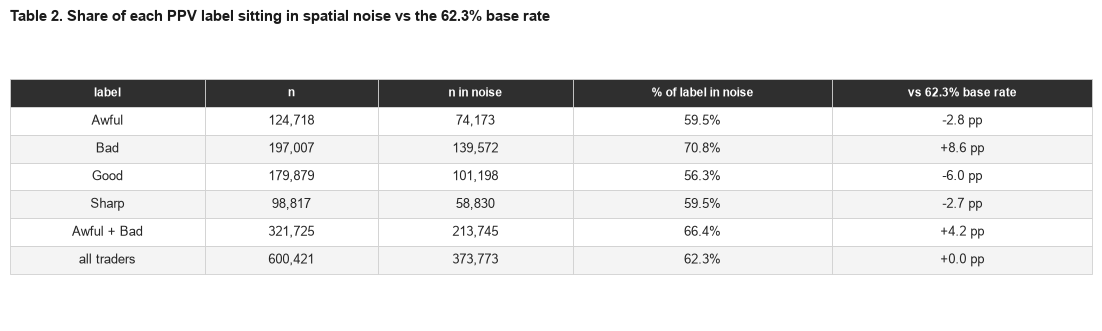

saved /Users/lilyshen/polymarket-analysis/figures/table_base_rate.png


PosixPath('/Users/lilyshen/polymarket-analysis/figures/table_base_rate.png')

In [22]:
base_rate = float(NOISE.mean())
print(f"noise base rate: {100*base_rate:.1f}%  ({int(NOISE.sum()):,} / {len(df):,})")

def _base_row(name, mask):
    tot = int(mask.sum())
    inn = int((mask & NOISE).sum())
    pct = inn / tot if tot else float("nan")
    delta_pp = 100 * (pct - base_rate)
    return {
        "label": name,
        "n": f"{tot:,}",
        "n_in_noise": f"{inn:,}",
        "pct_of_label_in_noise": f"{100*pct:.1f}%",
        "vs_62.3pct_base": f"{delta_pp:+.1f} pp",
    }

base = pd.DataFrame([
    _base_row("Awful", df["_awful"]),
    _base_row("Bad", df["_bad"]),
    _base_row("Good", df["_good"]),
    _base_row("Sharp", df["_sharp"]),
    _base_row("Awful + Bad", df["_awful"] | df["_bad"]),
    _base_row("all traders", pd.Series(True, index=df.index)),
])
display(base)
_paper_table(
    base,
    col_labels=["label", "n", "n in noise", "% of label in noise", "vs 62.3% base rate"],
    title="Table 2. Share of each PPV label sitting in spatial noise vs the 62.3% base rate",
    out_name="table_base_rate.png",
    col_widths=[0.18, 0.16, 0.18, 0.24, 0.24],
)

**Table 2 caption.** 62.3% of the cleaned sample is spatial noise. 66.4% of Awful+Bad wallets are noise — only **+4.2 pp** above that base rate. Sharps are **59.5%** in noise, essentially the same as Awfuls (**59.5%**). Bads are the only label clearly over-represented in noise (+8.6 pp). Losers are not “scattered” in a way Sharps are not; both sit in the aisle at about the same rate.

## Table 3 — book-impact degeneracy

The red clustering axis is `price_levels_consumed_vw` (volume-weighted book levels consumed). After z-score it still barely moves for almost everyone: most wallets sit on a single plane. The “3D LiDAR” is effectively **2D** (time-of-day dispersion $\times$ log clip size).

,statistic,value
0,share with book impact exactly 0,68.9%
1,median book impact,0
2,z-score of the zero pile,-0.034
3,share within 0.05 z of the zero pile,97.1%
4,99th percentile of z(book),0.33
5,max z(book),293
6,median z(std_time_vw),-0.14
7,median z(log_mean_tx_value),-0.16


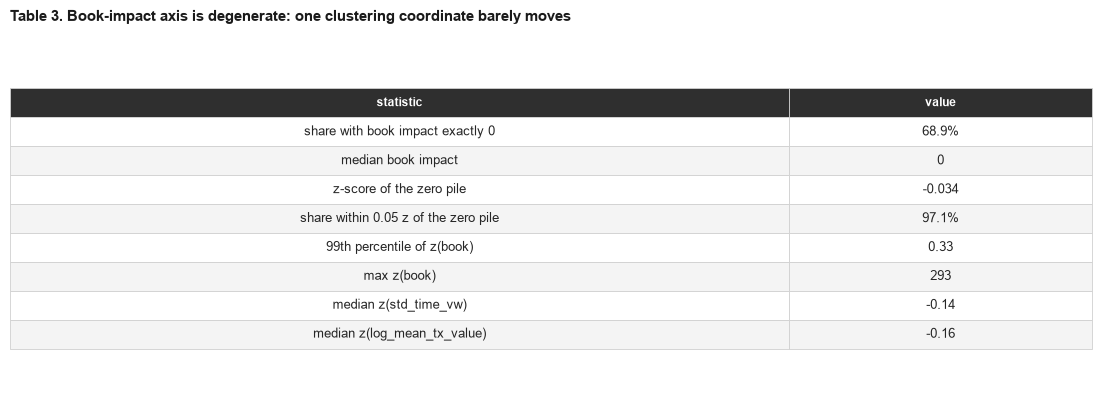

saved /Users/lilyshen/polymarket-analysis/figures/table_book_impact_degeneracy.png


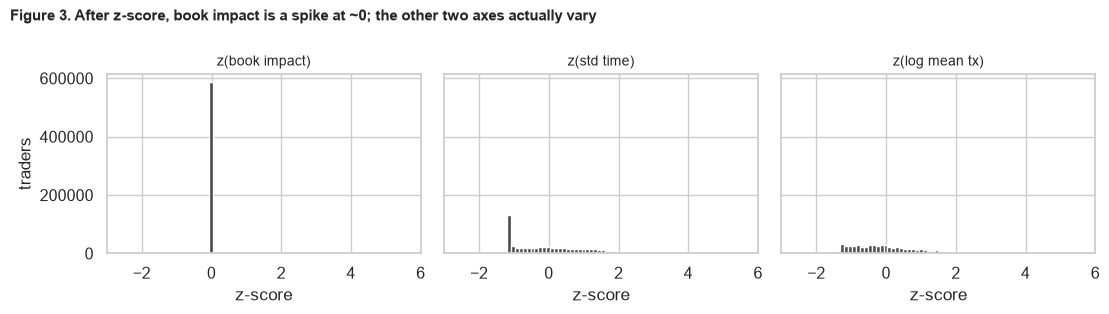

In [19]:
book = df["price_levels_consumed_vw"].astype(float)
z_book = (book - book.mean()) / book.std(ddof=0)
z_at_zero = float(z_book.loc[book == 0].iloc[0])
near_pile = np.abs(z_book - z_at_zero) < 0.05

degen = pd.DataFrame([
    {"statistic": "share with book impact exactly 0", "value": f"{100*(book==0).mean():.1f}%"},
    {"statistic": "median book impact", "value": f"{book.median():.0f}"},
    {"statistic": "z-score of the zero pile", "value": f"{z_at_zero:.3f}"},
    {"statistic": "share within 0.05 z of the zero pile", "value": f"{100*near_pile.mean():.1f}%"},
    {"statistic": "99th percentile of z(book)", "value": f"{z_book.quantile(0.99):.2f}"},
    {"statistic": "max z(book)", "value": f"{z_book.max():.0f}"},
    {"statistic": "median z(std_time_vw)", "value": f"{df['z_std_time_vw'].median():.2f}"},
    {"statistic": "median z(log_mean_tx_value)", "value": f"{df['z_log_mean_tx_value'].median():.2f}"},
])
display(degen)
_paper_table(
    degen,
    col_labels=["statistic", "value"],
    title="Table 3. Book-impact axis is degenerate: one clustering coordinate barely moves",
    out_name="table_book_impact_degeneracy.png",
    col_widths=[0.72, 0.28],
)

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.2), sharey=True)
for ax, col, title in [
    (axes[0], "z_price_levels_consumed_vw", "z(book impact)"),
    (axes[1], "z_std_time_vw", "z(std time)"),
    (axes[2], "z_log_mean_tx_value", "z(log mean tx)"),
]:
    ax.hist(df[col], bins=80, color="#4a4a4a", range=(-3, 6))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("z-score")
    ax.set_xlim(-3, 6)
axes[0].set_ylabel("traders")
fig.suptitle(
    "After z-score, book impact is a spike at ~0; the other two axes actually vary",
    fontsize=11, fontweight="bold", x=0.01, ha="left",
)
fig.tight_layout()
fig.savefig(FIGURES / "book_impact_degeneracy_hist.png", dpi=220, bbox_inches="tight", facecolor="white")
plt.show()

**Table 3 caption.** 68.9% of wallets have `price_levels_consumed_vw` exactly 0. After StandardScaler that pile sits at $z\approx -0.034$, and **97.1%** of the sample is within 0.05 z of it. The 99th percentile of z(book) is only 0.33; a handful of whales stretch the max to ~293 and give the axis a fake sense of range. HDBSCAN is therefore clustering mostly on `std_time_vw` and `log_mean_tx_value`. The red axis in the viewer looking like a pancake is the data, not a camera bug.